# Bahraini Currency Classification (CNN - Functional API)

Guided Lab: image classification of Bahraini currency notes (BHD).

Structure follows the same workflow as `03_nn_Functional_API.ipynb`, adapted for real RGB currency images instead of Fashion MNIST.

## 1. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf

from tensorflow.keras.utils import set_random_seed
import random

seed = 100
random.seed(seed)
np.random.seed(seed)
set_random_seed(seed)

## 2. Loading the Data

Assumes this folder structure (one folder per class, as agreed):

```
data/
  0.5_BHD/
  1_BHD/
  5_BHD/
  10_BHD/
  20_BHD/
  ... (10+ classes)
```

Replace `DATA_DIR` with the path to your `data` folder (e.g. after uploading/mounting it in Colab).

In [2]:
import zipfile

with zipfile.ZipFile("Money.zip", 'r') as zip_ref:
    zip_ref.extractall("Money")

In [3]:
import os

for root, dirs, files in os.walk("Money"):
    print(root, "->", len(files), "files", dirs)

Money -> 0 files ['Money']
Money\Money -> 0 files ['10BD', '1BD', '20BD', '500 Fils', '5BD']
Money\Money\10BD -> 230 files []
Money\Money\1BD -> 230 files []
Money\Money\20BD -> 230 files []
Money\Money\500 Fils -> 230 files []
Money\Money\5BD -> 230 files []


In [5]:
import os

for root, dirs, files in os.walk("Money/Money"):
    for f in files[:3]:  # أول 3 ملفات بس من كل مجلد
        print(os.path.join(root, f))

Money/Money\10BD\10_0000.jpg
Money/Money\10BD\10_0001.jpg
Money/Money\10BD\10_0002.jpg
Money/Money\1BD\1_0000.jpg
Money/Money\1BD\1_0001.jpg
Money/Money\1BD\1_0002.jpg
Money/Money\20BD\20_0000.jpg
Money/Money\20BD\20_0001.jpg
Money/Money\20BD\20_0002.jpg
Money/Money\500 Fils\0.5_0000.jpg
Money/Money\500 Fils\0.5_0001.jpg
Money/Money\500 Fils\0.5_0002.jpg
Money/Money\5BD\5_0000.jpg
Money/Money\5BD\5_0001.jpg
Money/Money\5BD\5_0002.jpg


In [9]:
!pip install pillow-heif -q

from PIL import Image
import pillow_heif
import os

pillow_heif.register_heif_opener()

converted = 0
for root, dirs, files in os.walk("money 2/money"):
    for f in files:
        path = os.path.join(root, f)

        # حذف ملفات نظام ماك المخفية
        if f == ".DS_Store":
            os.remove(path)
            continue

        # تحويل HEIC/heic إلى jpg
        if f.lower().endswith(".heic"):
            img = Image.open(path).convert("RGB")
            new_path = os.path.splitext(path)[0] + ".jpg"
            img.save(new_path, "JPEG")
            os.remove(path)
            converted += 1

print(f"تم تحويل {converted} صورة")

تم تحويل 0 صورة



[notice] A new release of pip is available: 25.1.1 -> 26.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
DATA_DIR = "Money/Money"   # <-- change this to your dataset path
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="training",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    DATA_DIR,
    validation_split=0.2,
    subset="validation",
    seed=seed,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
num_classes = len(class_names)
print(class_names)

Found 69 files belonging to 6 classes.
Using 56 files for training.
Found 69 files belonging to 6 classes.
Using 13 files for validation.
['0.500', '1', '10', '20', '5', 'background']


### Quick look at the data

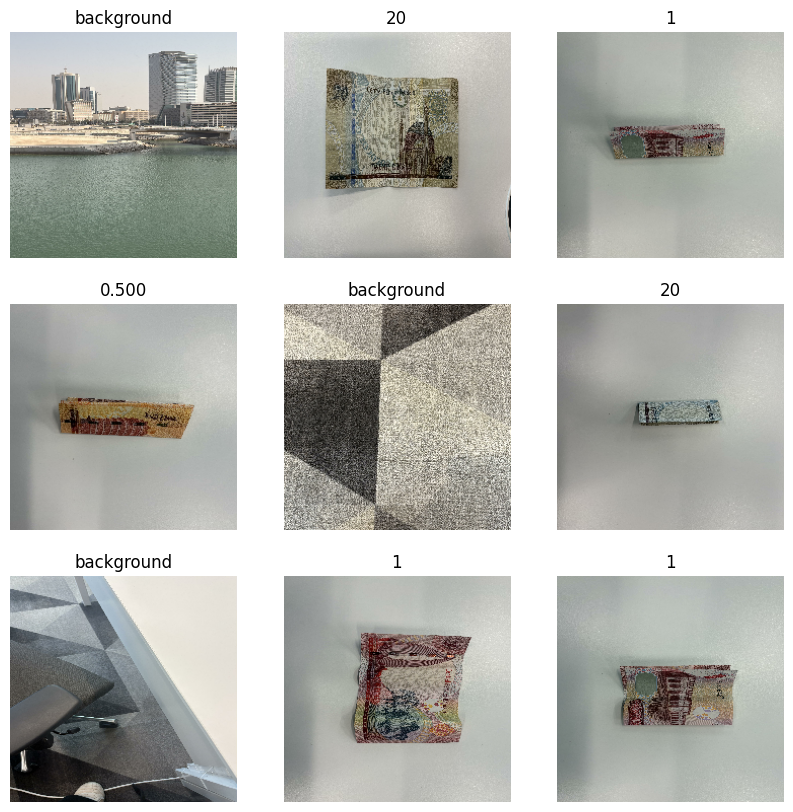

In [11]:
plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
    for i in range(min(9, images.shape[0])):
        plt.subplot(3, 3, i + 1)
        plt.imshow(images[i].numpy().astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
plt.show()

In [12]:
# check class balance
counts = {}
for _, labels in train_ds.unbatch():
    name = class_names[int(labels)]
    counts[name] = counts.get(name, 0) + 1

pd.Series(counts).sort_values(ascending=False)

background    14
20             9
10             9
5              8
0.500          8
1              8
dtype: int64

## 3. Preprocessing

- Resizing: already done by `image_dataset_from_directory` (224x224)
- Normalization: `Rescaling(1./255)` inside the model
- Data augmentation: rotation, zoom, horizontal flip, brightness (train set only)

In [13]:
from tensorflow.keras.layers import Rescaling
from tensorflow.keras import layers

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomBrightness(0.1),
], name="data_augmentation")

# performance: cache + prefetch
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

## 4. Modeling using Functional API

CNN instead of flattening the raw image directly (images are RGB 224x224x3, not simple 28x28 grayscale).

In [14]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, Flatten, Dense, Dropout

inputs = Input(shape=(224, 224, 3))

x = data_augmentation(inputs)
x = Rescaling(1./255)(x)

x = Conv2D(32, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(64, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Conv2D(128, 3, activation="relu")(x)
x = MaxPooling2D()(x)

x = Flatten()(x)
x = Dense(128, activation="relu")(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation="softmax")(x)

model = Model(inputs=inputs, outputs=outputs)
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ data_augmentation (Sequential)       │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 224, 224, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 222, 222, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 111, 111, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 109, 109, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 54, 54, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 52, 52, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 26, 26, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 86528)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 128)                 │      11,075,712 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 6)                   │             774 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,169,734 (42.61 MB)

 Trainable params: 11,169,734 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Compile & Train

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

es = EarlyStopping(patience=5, restore_best_weights=True)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[es],
)

Epoch 1/50


C:\Users\user\PycharmProjects\PythonProject\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


2/2 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.1429 - loss: 4.9412 - val_accuracy: 0.0769 - val_loss: 3.4956
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.2321 - loss: 2.5922 - val_accuracy: 0.1538 - val_loss: 1.8480
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2500 - loss: 1.7909 - val_accuracy: 0.3846 - val_loss: 1.6770
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2143 - loss: 1.7674 - val_accuracy: 0.3846 - val_loss: 1.6885
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 865ms/step - accuracy: 0.2321 - loss: 1.7898 - val_accuracy: 0.3846 - val_loss: 1.6254
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 794ms/step - accuracy: 0.2143 - loss: 1.7410 - val_accuracy: 0.3846 - val_loss: 1.5393
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2679 - loss: 1.7024 - val_accuracy: 0.3846 - val_loss: 1.4374
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 1s/step - accuracy: 0.2679 - loss: 1.6652 - val_accuracy: 0.3846 - val_loss: 1.3378
Epoch 9/50
2/2 ━━━━━━

## 6. Training History

<Axes: title={'center': 'Loss'}>

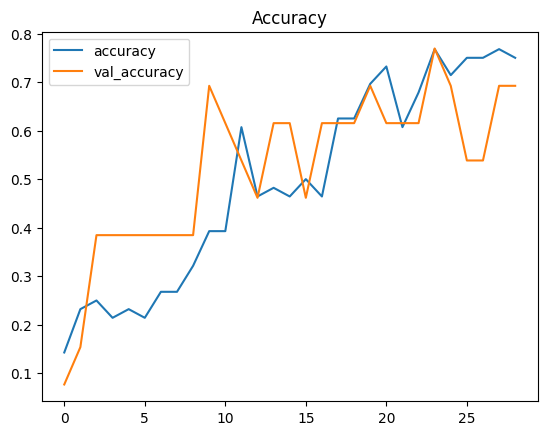

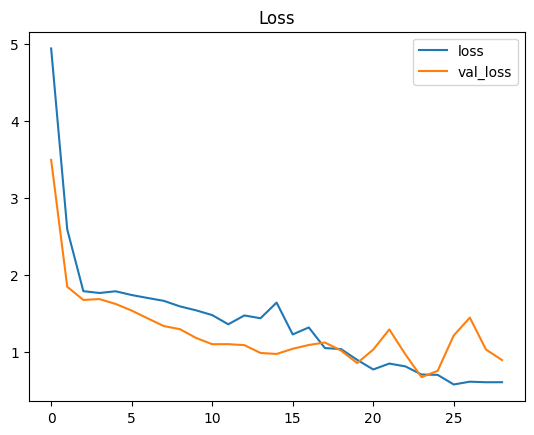

In [16]:
history_df = pd.DataFrame(history.history)
history_df[['accuracy', 'val_accuracy']].plot(title="Accuracy")
history_df[['loss', 'val_loss']].plot(title="Loss")

### (Optional) Class Weights
Use this only if the dataset turns out imbalanced across currency classes (check the counts above).

In [21]:
from sklearn.utils import compute_class_weight

y_train_labels = np.array([y.numpy() for _, y in train_ds.unbatch()])
class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_labels),
    y=y_train_labels,
)
class_weights = dict(enumerate(class_weights))
class_weights

{0: np.float64(1.1666666666666667),
 1: np.float64(1.1666666666666667),
 2: np.float64(1.037037037037037),
 3: np.float64(1.037037037037037),
 4: np.float64(1.1666666666666667),
 5: np.float64(0.6666666666666666)}

## 7. Evaluation

Accuracy, confusion matrix, precision/recall, per-class performance.

In [23]:
y_true = np.array([y.numpy() for _, y in val_ds.unbatch()])
y_pred_probs = model.predict(val_ds)
y_pred = np.argmax(y_pred_probs, axis=1)

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

print("Accuracy:", accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 613ms/step
Accuracy: 0.7692307692307693
              precision    recall  f1-score   support

       0.500       1.00      0.50      0.67         2
           1       0.50      1.00      0.67         2
          10       0.00      0.00      0.00         1
          20       0.00      0.00      0.00         1
           5       0.67      1.00      0.80         2
  background       1.00      1.00      1.00         5

    accuracy                           0.77        13
   macro avg       0.53      0.58      0.52        13
weighted avg       0.72      0.77      0.71        13



C:\Users\user\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\user\PycharmProjects\PythonProject\.venv\Lib\site-packages\sklearn\metrics\_classification.py:1879: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier,

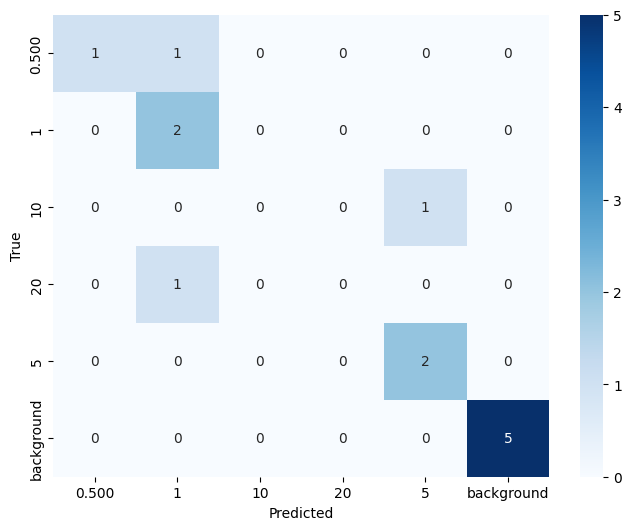

In [24]:
conf_matrix = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, cmap="Blues", fmt="g",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

## 8. Error Analysis

Look at misclassified images — which currency notes get confused with each other?

3 misclassified out of 13


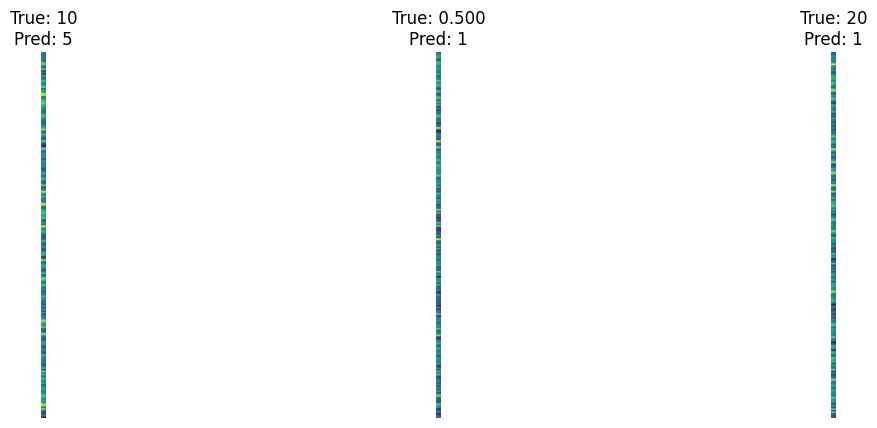

In [25]:
val_images = np.concatenate([x for x, _ in val_ds.unbatch()])
wrong_idx = np.where(y_true != y_pred)[0]
print(f"{len(wrong_idx)} misclassified out of {len(y_true)}")

plt.figure(figsize=(12, 12))
for i, idx in enumerate(wrong_idx[:9]):
    plt.subplot(3, 3, i + 1)
    plt.imshow(val_images[idx].astype("uint8"))
    plt.title(f"True: {class_names[y_true[idx]]}\nPred: {class_names[y_pred[idx]]}")
    plt.axis("off")
plt.tight_layout()
plt.show()

## 9. Save the Model

Needed for the Streamlit deployment step (real-world testing).

In [27]:
model.save("bahraini_currency_model.keras")

## 10. Final Reflection

1. Why did classification work well initially?
2. What problems did object detection solve (compared to classification)?
3. Which approach is more suitable for real-world deployment?
4. How would you improve the system further?

_(Answer here based on your confusion matrix and error analysis above.)_